In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [2]:
dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.24MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 140kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.54MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



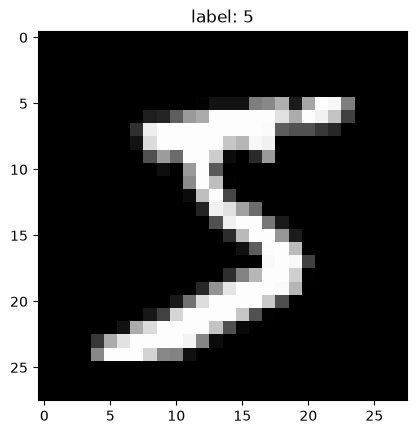

In [3]:
img, label = dataset[0]
plt.imshow(img, cmap="gray")
plt.title(f"label: {label}")
plt.show()

# forward process

In [4]:
import torch

In [5]:
T = 1000
beta = torch.linspace(0.0001, 0.02, T)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

In [6]:
def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)

    sqrt_alpha_bar = torch.sqrt(alpha_bar[t])
    sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar[t])

    x_t = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise

    return x_t, noise

# MNIST 이미지 : 여러 timestep을 한 줄로 나란히 그리는 코드

In [7]:
import matplotlib.pyplot as plt
from torchvision import transforms

In [8]:
to_tensor = transforms.ToTensor()
img, label = dataset[0]
x0 = to_tensor(img)

In [9]:
timesteps = [0, 50, 100, 250, 500, 750, 999]

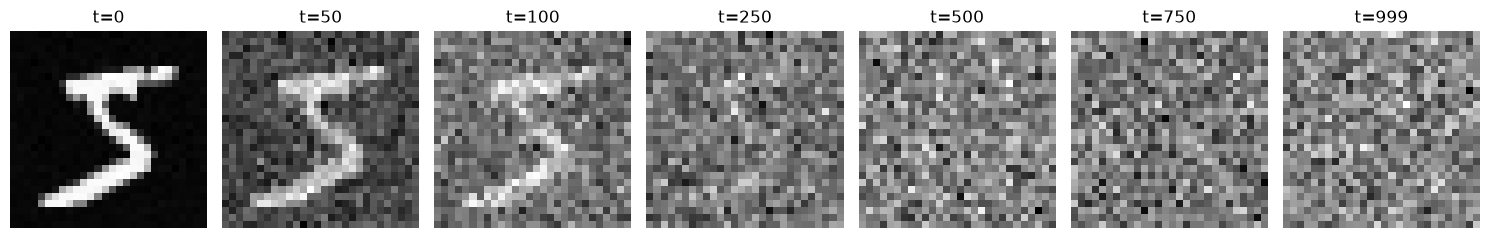

In [10]:
fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 3))

for i, t in enumerate(timesteps):
    x_t, noise = forward_diffusion(x0, t)
    axes[i].imshow(x_t.squeeze(), cmap="gray")
    axes[i].set_title(f"t={t}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# 노이즈를 예측하는 네트워크 + 학습 루프

In [11]:
import torch
import torch.nn as nn
import math

In [12]:
# timestep embedding 함수

def sinusoidal_embedding(t, dim=32):
    half_dim = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim) / half_dim)
    args = t[:, None].float() * freqs[None, :]
    embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return embedding


In [13]:
# 노이즈 예측 네트워크 (아주 작은  CNN)

class SimpleNoisePredictor(nn.Module):
    def __init__(self, time_dim=32):
        super().__init__()
        self.time_mlp = nn.Linear(time_dim, 32)

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 1, 3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x, t_embed):
        t_feat = self.time_mlp(t_embed)
        t_feat = t_feat[:, :, None, None]

        h = self.relu(self.conv1(x))
        h = h + t_feat
        h = self.relu(self.conv2(h))
        out = self.conv3(h)
        return out


In [14]:
# 학습 루프 (L_simple을 코드로 구현하기)

model = SimpleNoisePredictor()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()